In [18]:
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load the model
model = cobra.io.read_sbml_model("../model.xml")

In [24]:
ecoli_model = cobra.io.read_sbml_model("/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/ecoli/iJO1366.xml")

In [14]:
# Define a minimal media without C or N
minimal_media = {
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00007_e0": 20,  # O2_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [31]:
# Define carbon sources to test
c_source = {"Glucose": {"modelseed": "EX_cpd00027_e0", "bigg": "EX_glc__D_e"},
            "Acetate": {"modelseed": "EX_cpd00029_e0", "bigg": "EX_ac_e"},
            "Pyruvate": {"modelseed": "EX_cpd00020_e0", "bigg": "EX_pyr_e"},
            "Succinate": {"modelseed": "EX_cpd00036_e0", "bigg": "EX_succ_e"}}

In [32]:
# Define nitrogen sources to test
n_source = {"Ammonia": {"modelseed": "EX_cpd00013_e0", "bigg": "EX_nh4_e"},
            "Nitrate": {"modelseed": "EX_cpd00209_e0", "bigg": "EX_no3_e"}}

In [38]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, test growth
for c_name, c_dict in c_source.items():
    # Extract the modelseed ID for the carbon source
    c_id = c_dict["modelseed"]
    for n_name, n_dict in n_source.items():
        # Extract the modelseed ID for the nitrogrn source
        n_id = n_dict["modelseed"]

        # Create a copy of the minimal media
        media = minimal_media.copy()

        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        # Add the carbon and nitrogen sources to the media
        media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
        media[n_id] = 1000
        
        # Set the minimal media
        model.medium = media
        
        # Optimize the model
        solution = model.optimize()
        
        # Store the results
        results_list.append({
            "Carbon Source": c_name,
            "Nitrogen Source": n_name,
            "Media": media,
            "Growth Rate": solution.objective_value
        })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

In [34]:
results

,Carbon Source,Nitrogen Source,Media,Growth Rate
0,Glucose,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",6.744525e-01
1,Glucose,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",5.666077e-01
2,Acetate,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",1.360883e-01
3,Acetate,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",-1.445613e-15
4,Pyruvate,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",3.837717e-01
5,Pyruvate,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",2.825166e-01
6,Succinate,Ammonia,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",2.403788e-01
7,Succinate,Nitrate,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",2.949474e-14


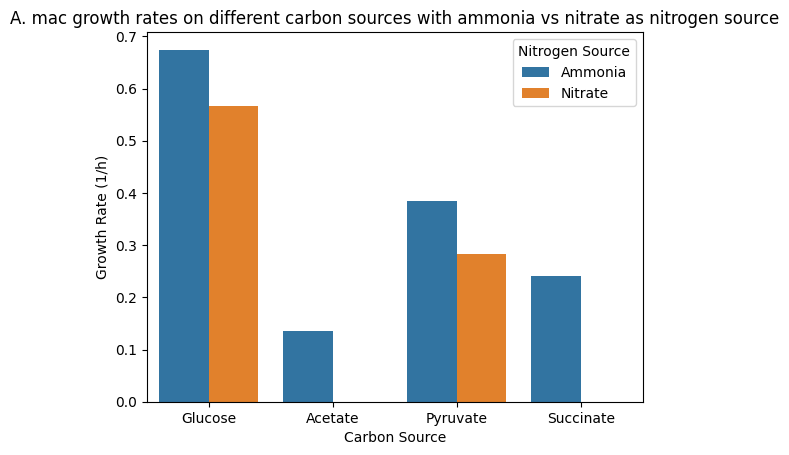

In [43]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
sns.barplot(data=results, x="Carbon Source", y="Growth Rate", hue="Nitrogen Source")
plt.title("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
plt.ylabel("Growth Rate (1/h)")
plt.xlabel("Carbon Source")
plt.legend(title="Nitrogen Source")
plt.show()

## E. coli

In [26]:
ecoli_minimal_media = {
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_ni2_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_slnt_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0
 }

In [39]:
# Make a list to store results
ecoli_results_list = []

# For each carbon and nitrogen source, test growth
for c_name, c_dict in c_source.items():
    # Extract the modelseed ID for the carbon source
    c_id = c_dict["bigg"]
    for n_name, n_dict in n_source.items():
        # Extract the modelseed ID for the nitrogen source
        n_id = n_dict["bigg"]

        # Create a copy of the minimal media
        media = ecoli_minimal_media.copy()

        # Find the metabolite for the carbon source
        carbon_metabolite = ecoli_model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        # Add the carbon and nitrogen sources to the media
        media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
        media[n_id] = 1000
        
        # Set the minimal media
        ecoli_model.medium = media
        
        # Optimize the model
        solution = ecoli_model.optimize()
        
        # Store the results
        ecoli_results_list.append({
            "Carbon Source": c_name,
            "Nitrogen Source": n_name,
            "Media": media,
            "Growth Rate": solution.objective_value
        })

# Create a dataframe from the list of results
ecoli_results = pd.DataFrame(ecoli_results_list)

In [40]:
ecoli_results

,Carbon Source,Nitrogen Source,Media,Growth Rate
0,Glucose,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372
1,Glucose,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.849220
2,Acetate,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.767837
3,Acetate,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.663385
4,Pyruvate,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.732137
5,Pyruvate,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.636396
6,Succinate,Ammonia,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.745510
7,Succinate,Nitrate,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.641128


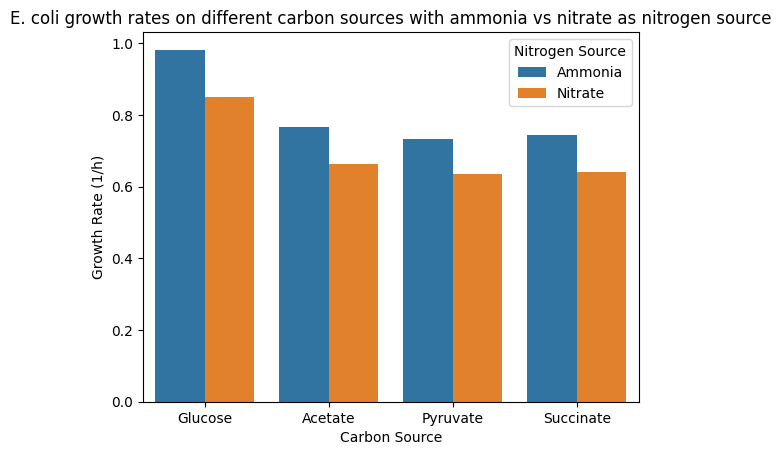

In [44]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
sns.barplot(data=ecoli_results, x="Carbon Source", y="Growth Rate", hue="Nitrogen Source")
plt.title("E. coli growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
plt.ylabel("Growth Rate (1/h)")
plt.xlabel("Carbon Source")
plt.legend(title="Nitrogen Source")
plt.show()

In [45]:
cobra.manipulation.check_mass_balance(model)

{<Reaction rxn10126_c0 at 0x116453d10>: {'C': -49.0, 'H': -76.0, 'O': -4.0},
 <Reaction rxn08556_c0 at 0x1164c3dd0>: {'C': -49.0, 'H': -76.0, 'O': -4.0},
 <Reaction rxn08792_c0 at 0x117ce6790>: {'C': -49.0, 'H': -76.0, 'O': -4.0},
 <Reaction rxn05296_c0 at 0x117e837d0>: {'charge': -1.1990333335943006,
  'H': -55.87497693167157,
  'O': -8.051088903379139,
  'C': -33.95928986458722,
  'N': -8.838628717915412,
  'S': -0.36173518565949303,
  'R': 2.0},
 <Reaction rxn08783_c0 at 0x118093bd0>: {'C': -49.0, 'H': -76.0, 'O': -4.0},
 <Reaction rxn08975_c0 at 0x1180ab290>: {'C': -49.0, 'H': -76.0, 'O': -4.0},
 <Reaction rxn05294_c0 at 0x117faec50>: {'charge': -2.0000000000000115,
  'C': -5.148868603416695,
  'H': -2.315245168395329,
  'N': -7.749564847467959,
  'O': 0.6006962440512922,
  'P': -0.06655062599144834,
  'R': 3.0},
 <Reaction rxn05295_c0 at 0x118291510>: {'charge': -3.552713678800501e-15,
  'C': -19.18613309220065,
  'H': -23.59029552989279,
  'N': -7.911477251708783,
  'O': -13.9211

In [46]:
model.reactions.rxn14412_c0

Reaction identifier,rxn14412_c0
Name,cytochrome-c reductase (ubiquinol: 2 protons) [c0]
Memory address,0x118454890
Stoichiometry,2.0 cpd00109_c0 --> 2.0 cpd00067_e0 + 2.0 cpd00110_c0 + cpd15560_c0 2.0 Cytochrome c3+ --> 2.0 H+ [e0] + 2.0 Cytochrome c2+ + Ubiquinone-8
GPR,WP_049586160.1 and WP_049586157.1
Lower bound,0.0
Upper bound,1000.0


In [74]:
from collections import Counter

reactant_elements = Counter()
product_elements = Counter()

for m, s in model.reactions.rxn14412_c0.metabolites.items():
    # Make a copy to avoid modifying the original metabolite's element dictionary
    elements = m.elements.copy()
    
    if s < 0:  # It's a reactant
        # Multiply by the absolute value of the stoichiometric coefficient
        for key in elements:
            elements[key] *= abs(s)
        reactant_elements += Counter(elements)
    else:  # It's a product
        for key in elements:
            elements[key] *= s
        product_elements += Counter(elements)

print("Reactant Elements:", reactant_elements)
print("Product Elements:", product_elements)

# Check if they are balanced
if reactant_elements == product_elements:
    print("The reaction is mass-balanced.")
else:
    print("The reaction is not mass-balanced.")
    print("Difference (Reactants - Products):", reactant_elements - product_elements)
    print("Difference (Products - Reactants):", product_elements - reactant_elements)

Reactant Elements: Counter({'H': 104.0, 'C': 84.0, 'N': 16.0, 'O': 12.0, 'S': 4.0, 'Fe': 2.0})
Product Elements: Counter({'H': 180.0, 'C': 133.0, 'N': 16.0, 'O': 16.0, 'S': 4.0, 'Fe': 2.0})
The reaction is not mass-balanced.
Difference (Reactants - Products): Counter()
Difference (Products - Reactants): Counter({'H': 76.0, 'C': 49.0, 'O': 4.0})


In [65]:
model.reactions.rxn14412_c0.metabolites

{<Metabolite cpd00109_c0 at 0x1160b2650>: -2.0,
 <Metabolite cpd00067_e0 at 0x116219a10>: 2.0,
 <Metabolite cpd00110_c0 at 0x1160b2a90>: 2.0,
 <Metabolite cpd15560_c0 at 0x11620ff50>: 1.0}

In [ ]:
from collections import Counter

# Create a counter
c = Counter({"A": 1, "B": 2})
multiplier = 2

# Multiply each value in the counter by the multiplier
for key in c:
    c[key] *= multiplier

print(c)

TypeError: unsupported operand type(s) for *: 'int' and 'Counter'

In [75]:
model.reactions.rxn10126_c0

Reaction identifier,rxn10126_c0
Name,succinate dehyrdogenase [c0]
Memory address,0x116453d10
Stoichiometry,cpd00982_c0 + cpd15560_c0 --> cpd00015_c0 + cpd00067_c0 FADH2 + Ubiquinone-8 --> FAD + H+
GPR,WP_012518362.1 and WP_014949447.1 and WP_014949446.1 and WP_014949445.1
Lower bound,0.0
Upper bound,1000.0


In [76]:
model.metabolites.cpd03449_c0

Metabolite identifier,cpd03449_c0
Name,"2-Octaprenyl-3-methyl-5-hydroxy-6-methoxy-1,4-..."
Memory address,0x116115a90
Formula,C48H72O4
Compartment,c0
In 2 reaction(s),"rxn11946_c0, rxn04139_c0"


In [78]:
model.metabolites.cpd15561_c0

AttributeError: DictList has no attribute or entry cpd15561_c0

In [79]:
model.reactions.rxn11964_c0

AttributeError: DictList has no attribute or entry rxn11964_c0